# Phase 3 — Final Evaluation

Implements `EXPERIMENT_PLAN` §3 (final runs with 5 fresh held-out seeds) and the
§7 reported metrics.

**Inputs**
- `runs/_phase1_calibration.json` — budget anchor `N`, eval cadence `X`.
- `runs/_phase2_results.json` — the winning HP config per condition (written by
  `phase2_hp_search.ipynb` §6).

**What it does**
1. §3.1 Re-pretrain on normal with 5 fresh seeds using the winning B-normal HPs
   → `checkpoints/final_pretrained_normal_seed_{seed}.pt`. These runs double as
   the **B-normal** final condition.
2. §3.2 Run the from-scratch slippery baselines (**B-slippery**, **B-DR**) at
   `2N`, and the four transfer conditions (**E1–E4**) at `N`, each over the same
   5 fresh seeds. Transfer runs load the seed-matched fresh checkpoint.
3. §3.3 Aggregate the §7 metrics (final slippery return, slippery AUC,
   catastrophic-forgetting delta, per-map breakdown; mean ± std over 5 seeds) to
   `runs/_phase3_results.json`, then draw the §4.1 figures.

With `SAVE_EVAL_CHECKPOINTS = True` (set below), every run also dumps the agent's
weights at **each eval checkpoint** to `<run_dir>/ckpt_step_<env_steps>.pt`, so
you can later replay how the policy drove after each training increment.

Every cell is **resumable**: an existing `eval_log.jsonl` (or a saved
checkpoint) skips that run, so the notebook can be killed and restarted freely.

## 0. Setup

In [2]:
import json, math, pathlib
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from experiment.config import ExperimentConfig, FRICTION_NORMAL, FRICTION_SLIPPERY
from experiment.train import train
from experiment.run_io import read_jsonl

# ---- Phase 1 anchors ---------------------------------------------------
CALIB_PATH = pathlib.Path("runs/_phase1_calibration.json")
if not CALIB_PATH.exists():
    raise FileNotFoundError(f"{CALIB_PATH} not found. Run phase1_calibration.ipynb first.")
calib = json.loads(CALIB_PATH.read_text())
N: int = int(calib["N"])
X: int = int(calib["X"])

# ---- Phase 2 winners (handoff artifact written by phase2 §6) -----------
PHASE2_RESULTS = pathlib.Path("runs/_phase2_results.json")
if not PHASE2_RESULTS.exists():
    raise FileNotFoundError(
        f"{PHASE2_RESULTS} not found. Run phase2_hp_search.ipynb section 6 first "
        f"so the winning HP configs Phase 3 consumes are on disk."
    )
p2 = json.loads(PHASE2_RESULTS.read_text())
baseline_winners = p2["baseline_winners"]   # B-normal / B-slippery / B-DR
ft_winners       = p2["ft_winners"]         # E1..E4

print(f"N = {N:,} env steps   (2N = {2*N:,} for matched-compute baselines)")
print(f"X = {X:,} env steps   (~{N // X} eval points per N-step run)\n")
print("Phase 2 winning HPs:")
for c in ("B-normal", "B-slippery", "B-DR"):
    print(f"  {c:<11} {baseline_winners[c]['hp_id']}")
for e in ("E1", "E2", "E3", "E4"):
    w = ft_winners[e]
    print(f"  {e:<11} {w['hp_id']}  freeze={w['freeze_first']}")

# ---- top-level knobs ---------------------------------------------------
FINAL_SEEDS = (101, 102, 103, 104, 105)   # 5 fresh held-out seeds (plan §5/§6),
                                          # disjoint from the HP-search seeds (1,2,3)
DEVICE      = "cpu"
SAVE_DIR    = "runs"

PRETRAIN_SUBDIR = "phase3_pretrain"   # §3.1 — also serves as the B-normal final condition
FINAL_SUBDIR    = "phase3_final"      # §3.2 — B-slippery, B-DR, E1..E4

CHECKPOINTS_DIR = pathlib.Path("checkpoints"); CHECKPOINTS_DIR.mkdir(exist_ok=True)
PHASE3_RESULTS  = pathlib.Path(SAVE_DIR) / "_phase3_results.json"

# Final eval protocol (plan §6): 10 greedy episodes per (map x friction) cell,
# both frictions every X env steps. The env + greedy policy are deterministic
# (no env RNG; see car_env.py and phase2's note), so n_episodes>1 reproduces the
# same number bit-for-bit — kept at 10 to satisfy the spec; set EVAL_N_EP=1 for a
# 10x-faster, identical eval if you have verified determinism.
EVAL_EVERY     = X
EVAL_N_EP      = 1
EVAL_FRICTIONS = (FRICTION_NORMAL, FRICTION_SLIPPERY)

# Dump the agent's weights at EVERY eval checkpoint (not just the final one) to
# <run_dir>/ckpt_step_<env_steps>.pt, so the policy can be replayed/visualised
# after each training increment. ~N/X (and ~2N/X) files per run; each is small
# (~160 KB here) — a full Phase 3 sweep is on the order of a few hundred MB.
SAVE_EVAL_CHECKPOINTS = True

N = 150,000 env steps   (2N = 300,000 for matched-compute baselines)
X = 4,000 env steps   (~37 eval points per N-step run)

Phase 2 winning HPs:
  B-normal    b-lr0.0003-dec30pct
  B-slippery  b-lr0.0001-dec60pct
  B-DR        b-lr0.0001-dec60pct
  E1          f-lr3e-05-eps0.05  freeze=False
  E2          f-lr3e-05-eps0.2  freeze=True
  E3          f-lr0.0001-eps0.5  freeze=False
  E4          f-lr3e-05-eps0.5  freeze=True


## 1. Condition registry

Seven final conditions. The friction *regime* per from-scratch baseline is part
of the experiment definition (mirrors phase2's `BASELINE_CONDITIONS`); the
transfer conditions read their regime + freeze flag straight from the Phase 2
winners. Each condition knows where its per-seed run lives so §3.3 can score it.

In [3]:
def _ckpt_path(seed):
    """Fresh §3.1 pretrained checkpoint for a final seed."""
    return CHECKPOINTS_DIR / f"final_pretrained_normal_seed_{seed}.pt"

def _eval_log(logdir):
    return pathlib.Path(logdir) / "eval_log.jsonl"

# name -> dict(logdir(seed) -> run dir, is_transfer, budget, [friction_kwargs], [freeze_first])
CONDITIONS = {}

# B-normal IS the §3.1 pretrain run (dual duty per §3.2).
CONDITIONS["B-normal"] = dict(
    logdir      = lambda s: pathlib.Path(SAVE_DIR) / PRETRAIN_SUBDIR / f"seed_{s}",
    is_transfer = False,
    budget      = N,
)

# From-scratch slippery baselines (matched-compute 2N).
for name, fk in [
    ("B-slippery", dict(friction_mode="fixed", friction=FRICTION_SLIPPERY)),
    ("B-DR",       dict(friction_mode="dr",
                        friction_dr_low=FRICTION_SLIPPERY,
                        friction_dr_high=FRICTION_NORMAL)),
]:
    CONDITIONS[name] = dict(
        logdir          = lambda s, n=name: pathlib.Path(SAVE_DIR) / FINAL_SUBDIR / n / f"seed_{s}",
        is_transfer     = False,
        budget          = 2 * N,
        friction_kwargs = fk,
    )

# Transfer conditions (load fresh seed-matched checkpoint, budget N).
for e in ("E1", "E2", "E3", "E4"):
    CONDITIONS[e] = dict(
        logdir          = lambda s, n=e: pathlib.Path(SAVE_DIR) / FINAL_SUBDIR / n / f"seed_{s}",
        is_transfer     = True,
        budget          = N,
        freeze_first    = bool(ft_winners[e]["freeze_first"]),
        friction_kwargs = ft_winners[e]["friction_kwargs"],
    )

print("Phase 3 conditions:")
for n, c in CONDITIONS.items():
    extra = ""
    if c["is_transfer"]:
        extra = f"  freeze={c['freeze_first']}  {c['friction_kwargs'].get('friction_mode')}"
    print(f"  {n:<11} budget={c['budget']:>7,}  transfer={str(c['is_transfer']):<5}{extra}")

Phase 3 conditions:
  B-normal    budget=150,000  transfer=False
  B-slippery  budget=300,000  transfer=False
  B-DR        budget=300,000  transfer=False
  E1          budget=150,000  transfer=True   freeze=False  fixed
  E2          budget=150,000  transfer=True   freeze=True  fixed
  E3          budget=150,000  transfer=True   freeze=False  curriculum
  E4          budget=150,000  transfer=True   freeze=True  curriculum


## 2. §3.1 — Re-pretrain on normal with 5 fresh seeds

Winning B-normal HPs, budget `N`. Each final checkpoint is copied to
`checkpoints/final_pretrained_normal_seed_{seed}.pt` for the transfer conditions
below. These runs are simultaneously the **B-normal** final condition (§3.2), so
they eval on both frictions every `X` steps like every other final run.

In [4]:
best_normal = baseline_winners["B-normal"]["hp_config"]
print(f"Re-pretrain on normal — winning B-normal HPs: {best_normal}\n")

for seed in FINAL_SEEDS:
    out    = _ckpt_path(seed)
    logdir = CONDITIONS["B-normal"]["logdir"](seed)
    if out.exists() and _eval_log(logdir).exists():
        print(f"  skip seed={seed} (have {out.name} + eval log)")
        continue
    cfg = ExperimentConfig(
        run_name                   = PRETRAIN_SUBDIR,
        seed                       = seed,
        save_dir                   = SAVE_DIR,
        device                     = DEVICE,
        friction_mode              = "fixed",
        friction                   = FRICTION_NORMAL,
        max_env_steps              = N,
        eval_every_env_steps       = EVAL_EVERY,
        eval_n_episodes            = EVAL_N_EP,
        eval_frictions             = EVAL_FRICTIONS,
        save_checkpoint_every_eval = SAVE_EVAL_CHECKPOINTS,
        lr                         = best_normal["lr"],
        epsilon_start              = best_normal["epsilon_start"],
        epsilon_end                = best_normal["epsilon_end"],
        epsilon_decay_steps        = best_normal["epsilon_decay_steps"],
    )
    print(f"  pretrain seed={seed}  budget={N:,}")
    train(cfg, verbose=False)
    src = pathlib.Path(SAVE_DIR) / PRETRAIN_SUBDIR / f"seed_{seed}" / "final_checkpoint.pt"
    out.write_bytes(src.read_bytes())
    print(f"    -> wrote {out}")

print("\nSection 2 done.")

Re-pretrain on normal — winning B-normal HPs: {'id': 'b-lr0.0003-dec30pct', 'lr': 0.0003, 'epsilon_start': 1.0, 'epsilon_end': 0.05, 'epsilon_decay_steps': 45000}

  pretrain seed=101  budget=150,000
    -> wrote checkpoints\final_pretrained_normal_seed_101.pt
  pretrain seed=102  budget=150,000
    -> wrote checkpoints\final_pretrained_normal_seed_102.pt
  pretrain seed=103  budget=150,000
    -> wrote checkpoints\final_pretrained_normal_seed_103.pt
  pretrain seed=104  budget=150,000
    -> wrote checkpoints\final_pretrained_normal_seed_104.pt
  pretrain seed=105  budget=150,000
    -> wrote checkpoints\final_pretrained_normal_seed_105.pt

Section 2 done.


## 3. §3.2 — From-scratch slippery baselines (B-slippery, B-DR)

5 fresh seeds each at `2N` with the winning per-condition HPs. `epsilon_decay_steps`
in the stored `hp_config` was already computed against the matched `2N` search
budget, so it carries over unchanged.

In [5]:
for name in ("B-slippery", "B-DR"):
    hp     = baseline_winners[name]["hp_config"]
    fk     = CONDITIONS[name]["friction_kwargs"]
    budget = CONDITIONS[name]["budget"]
    print(f"{name}: winning HPs {hp['id']}  budget={budget:,}")
    for seed in FINAL_SEEDS:
        logdir = CONDITIONS[name]["logdir"](seed)
        if _eval_log(logdir).exists():
            print(f"  skip seed={seed} (have eval log)")
            continue
        cfg = ExperimentConfig(
            run_name                   = f"{FINAL_SUBDIR}/{name}",
            seed                       = seed,
            save_dir                   = SAVE_DIR,
            device                     = DEVICE,
            max_env_steps              = budget,
            eval_every_env_steps       = EVAL_EVERY,
            eval_n_episodes            = EVAL_N_EP,
            eval_frictions             = EVAL_FRICTIONS,
            save_checkpoint_every_eval = SAVE_EVAL_CHECKPOINTS,
            lr                         = hp["lr"],
            epsilon_start              = hp["epsilon_start"],
            epsilon_end                = hp["epsilon_end"],
            epsilon_decay_steps        = hp["epsilon_decay_steps"],
            **fk,
        )
        print(f"  run seed={seed}")
        train(cfg, verbose=False)

print("\nSection 3 done.")

B-slippery: winning HPs b-lr0.0001-dec60pct  budget=300,000
  run seed=101
  run seed=102
  run seed=103
  run seed=104
  run seed=105
B-DR: winning HPs b-lr0.0001-dec60pct  budget=300,000
  run seed=101
  run seed=102
  run seed=103
  run seed=104
  run seed=105

Section 3 done.


## 4. §3.2 — Transfer conditions (E1–E4)

Each loads the **fresh** seed-matched checkpoint from §3.1 (not the Phase 2
validation checkpoints), applies its fine-tune protocol (direct vs curriculum ×
full vs freeze-first), and trains for `N` env steps.

In [6]:
# Fresh pretrained checkpoints must exist for every final seed.
missing = [s for s in FINAL_SEEDS if not _ckpt_path(s).exists()]
if missing:
    raise RuntimeError(
        f"Missing fresh pretrained checkpoints for seeds {missing}. Re-run section 2."
    )

for e in ("E1", "E2", "E3", "E4"):
    hp     = ft_winners[e]["hp_config"]
    fk     = CONDITIONS[e]["friction_kwargs"]
    freeze = CONDITIONS[e]["freeze_first"]
    print(f"{e}: winning HPs {hp['id']}  freeze={freeze}  {fk.get('friction_mode')}")
    for seed in FINAL_SEEDS:
        logdir = CONDITIONS[e]["logdir"](seed)
        if _eval_log(logdir).exists():
            print(f"  skip seed={seed} (have eval log)")
            continue
        cfg = ExperimentConfig(
            run_name                   = f"{FINAL_SUBDIR}/{e}",
            seed                       = seed,
            save_dir                   = SAVE_DIR,
            device                     = DEVICE,
            max_env_steps              = N,
            eval_every_env_steps       = EVAL_EVERY,
            eval_n_episodes            = EVAL_N_EP,
            eval_frictions             = EVAL_FRICTIONS,
            save_checkpoint_every_eval = SAVE_EVAL_CHECKPOINTS,
            lr                         = hp["lr"],
            epsilon_start              = hp["epsilon_start"],
            epsilon_end                = hp["epsilon_end"],
            epsilon_decay_steps        = hp["epsilon_decay_steps"],
            **fk,
        )
        print(f"  run seed={seed}")
        train(
            cfg,
            pretrained_ckpt = str(_ckpt_path(seed)),
            freeze_first    = freeze,
            verbose         = False,
        )

print("\nSection 4 done.")

E1: winning HPs f-lr3e-05-eps0.05  freeze=False  fixed
  run seed=101
  run seed=102
  run seed=103
  run seed=104
  run seed=105
E2: winning HPs f-lr3e-05-eps0.2  freeze=True  fixed
  run seed=101
  run seed=102
  run seed=103
  run seed=104
  run seed=105
E3: winning HPs f-lr0.0001-eps0.5  freeze=False  curriculum
  run seed=101
  run seed=102
  run seed=103
  run seed=104
  run seed=105
E4: winning HPs f-lr3e-05-eps0.5  freeze=True  curriculum
  run seed=101
  run seed=102
  run seed=103
  run seed=104
  run seed=105

Section 4 done.


## 5. §3.3 — Aggregate the §7 reported metrics

Per condition, averaged over the 5 seeds (mean ± std):

- **Final mean return on slippery** — mean of the last 20% of slippery eval
  points (plan §7: "last 20% of training"), averaged across the 3 maps.
- **AUC of the slippery eval curve** — sample efficiency (trapezoidal, x-normalised).
- **Catastrophic forgetting** (transfer only) — drop in normal-friction return
  from the first to the last fine-tune eval point (positive = forgetting).
- **Per-map breakdown** — final return per (map × friction) cell.

In [7]:
def _curve(log, target_f):
    """Mean-across-maps eval return per checkpoint at one friction."""
    steps, vals = [], []
    for rec in log:
        cells = [c for c in rec["cells"] if math.isclose(c["friction"], target_f)]
        if not cells:
            continue
        steps.append(rec["env_steps"])
        vals.append(float(np.mean([c["return_mean"] for c in cells])))
    return np.array(steps), np.array(vals)

def _auc(steps, vals):
    """Trapezoidal AUC, normalised by the swept x-range (NumPy 2.0 trapezoid)."""
    if len(steps) < 2:
        return float("nan")
    return float(np.trapezoid(vals, steps) / (steps[-1] - steps[0]))

def _tail_mean(vals, tail_pct=0.20):
    """Mean over the last `tail_pct` of points (plan §7: last 20% of training)."""
    if len(vals) == 0:
        return float("nan")
    k = max(1, int(round(len(vals) * tail_pct)))
    return float(np.mean(vals[-k:]))

def _per_map_final(log, target_f, tail_pct=0.20):
    """Final return per map at target_f (tail-mean of that map's curve)."""
    by_map = defaultdict(list)
    for rec in log:
        for c in rec["cells"]:
            if math.isclose(c["friction"], target_f):
                by_map[c["map"]].append((rec["env_steps"], c["return_mean"]))
    out = {}
    for m, seq in by_map.items():
        seq.sort()
        out[m] = _tail_mean([v for _, v in seq], tail_pct)
    return out

def _mean_std(arr):
    a = np.array(arr, dtype=float)
    return [float(np.nanmean(a)), float(np.nanstd(a))]

report = {}
for name, c in CONDITIONS.items():
    final_slip, auc_slip, forget, permaps = [], [], [], []
    for seed in FINAL_SEEDS:
        lp = _eval_log(c["logdir"](seed))
        if not lp.exists():
            final_slip.append(np.nan); auc_slip.append(np.nan); forget.append(np.nan)
            permaps.append({}); continue
        log = read_jsonl(lp)
        s_slip, v_slip = _curve(log, FRICTION_SLIPPERY)
        final_slip.append(_tail_mean(v_slip))
        auc_slip.append(_auc(s_slip, v_slip))
        if c["is_transfer"]:
            _, v_norm = _curve(log, FRICTION_NORMAL)
            forget.append(float(v_norm[0] - v_norm[-1]) if len(v_norm) >= 2 else np.nan)
        else:
            forget.append(np.nan)
        pm = {}
        for f in EVAL_FRICTIONS:
            for m, val in _per_map_final(log, f).items():
                pm[f"{pathlib.Path(m).stem}|f={f:.2f}"] = val
        permaps.append(pm)

    keys = sorted({k for d in permaps for k in d})
    per_map_ms = {k: _mean_std([d.get(k, np.nan) for d in permaps]) for k in keys}
    report[name] = dict(
        is_transfer            = c["is_transfer"],
        budget                 = c["budget"],
        final_return_slippery  = _mean_std(final_slip),
        auc_slippery           = _mean_std(auc_slip),
        forgetting_normal      = (_mean_std(forget) if c["is_transfer"] else None),
        per_map_final          = per_map_ms,
        per_seed               = dict(
            final_slippery = [float(x) for x in final_slip],
            auc_slippery   = [float(x) for x in auc_slip],
            forgetting     = ([float(x) for x in forget] if c["is_transfer"] else None),
        ),
    )

# ---- table ----
print(f"{'condition':<11} {'final slip':>16} {'AUC slip':>16} {'forget(norm)':>16}")
print("-" * 64)
for n, r in report.items():
    fr, au = r["final_return_slippery"], r["auc_slippery"]
    fg = r["forgetting_normal"]
    fg_s = f"{fg[0]:+8.1f}±{fg[1]:<6.1f}" if fg else f"{'—':>15}"
    print(f"{n:<11} {fr[0]:>8.1f}±{fr[1]:<6.1f} {au[0]:>8.1f}±{au[1]:<6.1f} {fg_s}")

condition         final slip         AUC slip     forget(norm)
----------------------------------------------------------------
B-normal      1049.6±2236.7    689.7±791.5                —
B-slippery    5182.4±399.0    2934.8±512.4                —
B-DR          4771.4±442.5    4265.9±497.8                —
E1            2978.3±1910.8   1583.7±1050.7   -591.8±2578.3
E2            1689.1±724.4    1507.6±644.8   +1863.4±2775.5
E3            1361.3±1088.5   1306.8±1326.1  +2080.6±3472.5
E4             675.7±1175.0   1304.2±598.6   +1460.7±1833.3


## 6. Write Phase 3 results

In [8]:
result = dict(
    N               = N,
    X               = X,
    final_seeds     = list(FINAL_SEEDS),
    eval_n_episodes = EVAL_N_EP,
    phase2_results  = str(PHASE2_RESULTS),
    report          = report,
)
PHASE3_RESULTS.write_text(json.dumps(result, indent=2))
print(f"wrote {PHASE3_RESULTS}")

wrote runs\_phase3_results.json


## 7. Figures (§4.1)

1. **Main learning curves** — slippery eval return vs env steps, one line per
   condition, shaded band = ±1 std across the 5 seeds.
2. **Per-map heatmap** — final return per (condition × map × friction) cell.
3. **Forgetting plot** — normal-friction return over fine-tune steps for E1–E4.
4. **AUC bar chart** — slippery AUC per condition with seed-level error bars.

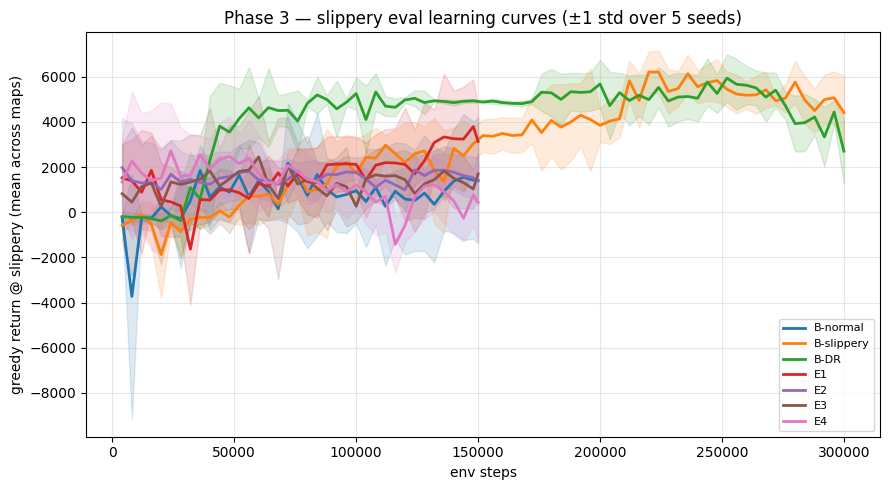

In [9]:
COND_ORDER = ["B-normal", "B-slippery", "B-DR", "E1", "E2", "E3", "E4"]

def _mean_curve_over_seeds(name, target_f):
    """Across-seed mean/std eval curve at target_f, aligned to the shortest seed."""
    curves = []
    for seed in FINAL_SEEDS:
        lp = _eval_log(CONDITIONS[name]["logdir"](seed))
        if not lp.exists():
            continue
        s, v = _curve(read_jsonl(lp), target_f)
        if len(s):
            curves.append((s, v))
    if not curves:
        return None, None, None
    m = min(len(v) for _, v in curves)
    steps = curves[0][0][:m]
    stack = np.stack([v[:m] for _, v in curves])
    return steps, stack.mean(0), stack.std(0)

# ---- 1. main learning curves (slippery) ----
plt.figure(figsize=(9, 5))
for name in COND_ORDER:
    steps, mean, std = _mean_curve_over_seeds(name, FRICTION_SLIPPERY)
    if steps is None:
        continue
    line, = plt.plot(steps, mean, lw=2, label=name)
    plt.fill_between(steps, mean - std, mean + std, color=line.get_color(), alpha=0.15)
plt.xlabel("env steps"); plt.ylabel("greedy return @ slippery (mean across maps)")
plt.title("Phase 3 — slippery eval learning curves (±1 std over 5 seeds)")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

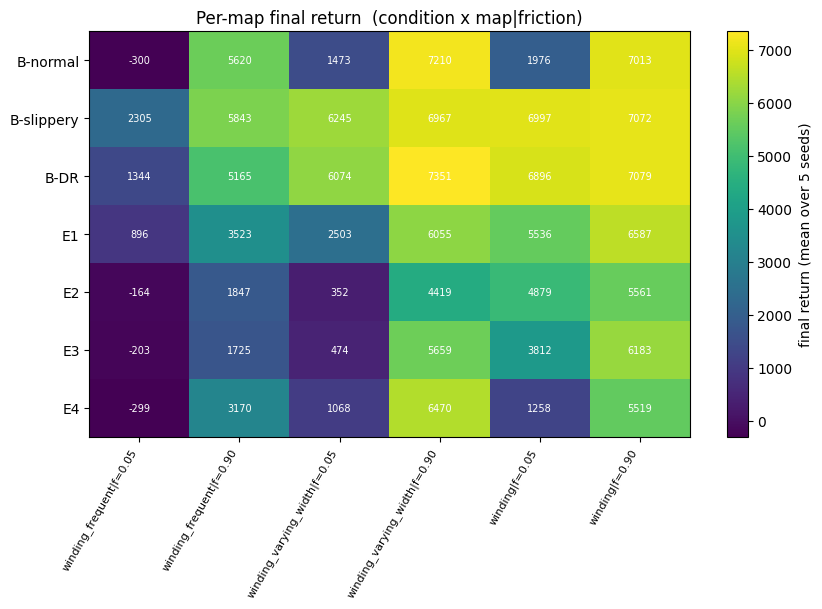

In [10]:
# ---- 2. per-map heatmap (final return per condition x cell) ----
cell_keys = sorted({k for r in report.values() for k in r["per_map_final"]})
mat = np.array([[report[n]["per_map_final"].get(k, [np.nan])[0] for k in cell_keys]
                for n in COND_ORDER], dtype=float)

fig, ax = plt.subplots(figsize=(1.1 * len(cell_keys) + 2, 0.6 * len(COND_ORDER) + 2))
im = ax.imshow(mat, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(cell_keys))); ax.set_xticklabels(cell_keys, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(COND_ORDER))); ax.set_yticklabels(COND_ORDER)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i, j]:.0f}", ha="center", va="center",
                    color="w", fontsize=7)
fig.colorbar(im, ax=ax, label="final return (mean over 5 seeds)")
ax.set_title("Per-map final return  (condition x map|friction)")
plt.tight_layout(); plt.show()

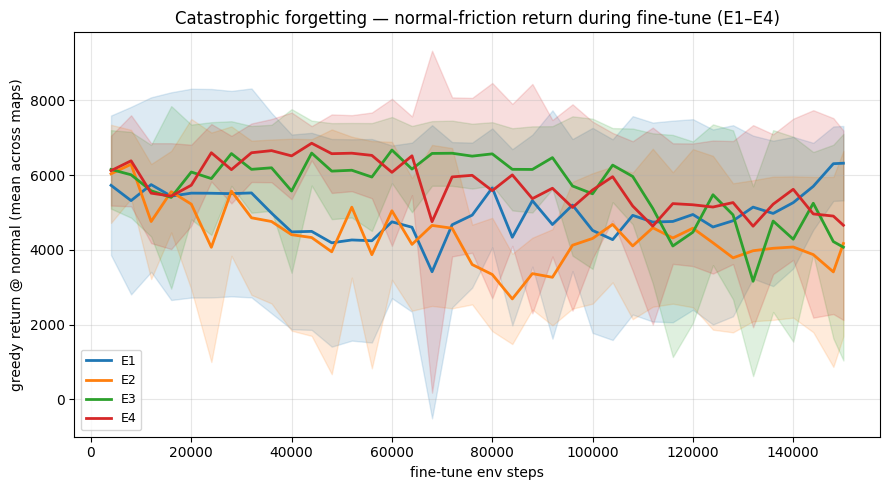

In [11]:
# ---- 3. catastrophic-forgetting curves (normal return over fine-tune) ----
plt.figure(figsize=(9, 5))
for name in ("E1", "E2", "E3", "E4"):
    steps, mean, std = _mean_curve_over_seeds(name, FRICTION_NORMAL)
    if steps is None:
        continue
    line, = plt.plot(steps, mean, lw=2, label=name)
    plt.fill_between(steps, mean - std, mean + std, color=line.get_color(), alpha=0.15)
plt.xlabel("fine-tune env steps"); plt.ylabel("greedy return @ normal (mean across maps)")
plt.title("Catastrophic forgetting — normal-friction return during fine-tune (E1–E4)")
plt.grid(alpha=0.3); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

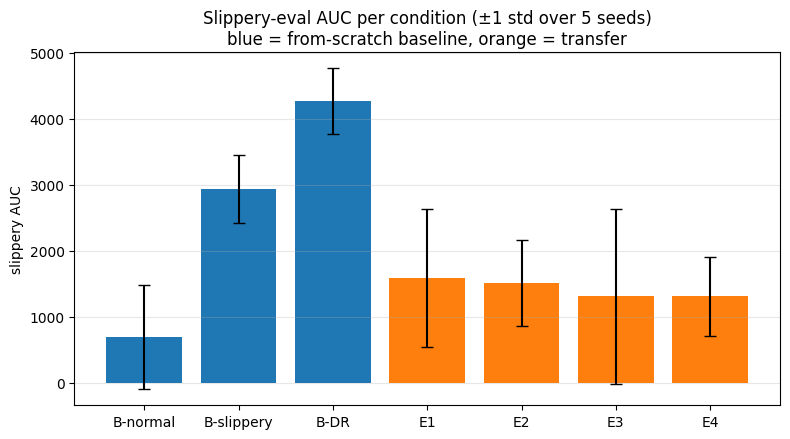

In [12]:
# ---- 4. slippery AUC bar chart with seed error bars ----
names  = [n for n in COND_ORDER if n in report]
means  = [report[n]["auc_slippery"][0] for n in names]
stds   = [report[n]["auc_slippery"][1] for n in names]
colors = ["tab:blue" if not report[n]["is_transfer"] else "tab:orange" for n in names]

plt.figure(figsize=(8, 4.5))
xs = np.arange(len(names))
plt.bar(xs, means, yerr=stds, color=colors, capsize=4)
plt.xticks(xs, names); plt.ylabel("slippery AUC")
plt.title("Slippery-eval AUC per condition (±1 std over 5 seeds)\nblue = from-scratch baseline, orange = transfer")
plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## 8. Inspect per-checkpoint weights (optional)

With `SAVE_EVAL_CHECKPOINTS = True`, each run dir holds one
`ckpt_step_<env_steps>.pt` per eval point. The helper below lists them for a
given condition/seed in step order; load any one with
`run_io.load_checkpoint_into` (same as `play_model.py`) to render a greedy
rollout and watch how the policy evolved over training.

In [ ]:
def list_step_checkpoints(condition, seed):
    """Per-eval checkpoints for one (condition, seed), sorted by env step."""
    logdir = CONDITIONS[condition]["logdir"](seed)
    ckpts = sorted(pathlib.Path(logdir).glob("ckpt_step_*.pt"))
    return [(int(p.stem.split("_")[-1]), p) for p in ckpts]

# Example: how many per-step checkpoints landed for E1, seed 101?
example = list_step_checkpoints("E1", FINAL_SEEDS[0])
print(f"E1 seed={FINAL_SEEDS[0]}: {len(example)} per-step checkpoints")
for step, path in example[:3] + example[-1:]:
    print(f"  step {step:>8,}  {path.name}")

## 9. Summary

If every cell ran cleanly:

- 5 fresh pretrained checkpoints in `checkpoints/final_pretrained_normal_seed_*.pt`.
- All final eval logs under `runs/phase3_pretrain/` and `runs/phase3_final/`,
  plus per-eval `ckpt_step_*.pt` weights in each run dir (when
  `SAVE_EVAL_CHECKPOINTS=True`).
- `runs/_phase3_results.json` holds every §7 metric (mean ± std and per-seed raw).

**Next — Phase 4 (write-up, plan §4):** the four figures above are the §4.1
deliverables. Pull the §7 numbers from `_phase3_results.json` for the results
table, use the §4.2 methodology paragraph / §4.3 limitations verbatim, and use
the per-step checkpoints (§8) to render policy-evolution rollouts.